# Frog-In-The-Pan -- a quantitative teardown
### yfinance panel * 12-1 momentum x information-discreteness * HAC inference * placebo

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does gradual beat jumpy%3F: Mixed](https://img.shields.io/badge/Does%20gradual%20beat%20jumpy%3F-Mixed-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test Da-Gurun-Warachka (2014): build the information-discreteness measure, double-sort 12-1 momentum by it, and race the low-ID WML against the high-ID WML.

> **Not investment advice.** Real data: yfinance daily adjusted-close, 38 S&P 500 large-caps, 2012-05-18--2025-12-30, as-of 2026-06-26, fp `e038fa42cc02`. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias is named on the SIGNAL axis:** a gradual decline into delisting is a low-ID loser, so the FIP slice is the *more* inflated of the two. Upper bounds.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from frog_in_the_pan import data, strategy as st

FRAC, COST_BPS, BORROW_BPS = 0.30, 5.0, 50.0

def _have_cache():
    return os.path.exists(os.path.join(os.path.abspath(".."), "_cache", "fip_prices.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices = data.drop_partial_last_month(data.fetch_panel())
    mp = st.to_monthly(prices)
    lo = st.long_short(mp, prices=prices, id_side="low",  frac=FRAC)
    hi = st.long_short(mp, prices=prices, id_side="high", frac=FRAC)
    base = st.long_short(mp, prices=None, frac=FRAC)
    s_lo, s_hi, s_base = st.summary(lo["wml_gross"]), st.summary(hi["wml_gross"]), st.summary(base["wml_gross"])
    fip = st.fip_spread(lo, hi); s_fip = st.summary(fip)
    print(f"N months: {s_lo['n']} | LOW-ID WML: {s_lo['mean']*100:+.2f}%/yr (t {s_lo['tstat']:+.2f})"
          f" | FIP gap: {s_fip['mean']*100:+.2f}%/yr (t {s_fip['tstat']:+.2f})")


yfinance cache present: True


N months: 151 | LOW-ID WML: -0.37%/yr (t -0.09) | FIP gap: +4.55%/yr (t +1.01)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | LOW-ID WML **-0.37%/yr** (HAC *t* **-0.09**); FIP interaction **+4.55%/yr** (HAC *t* **+1.01**). Placebo p = **0.56**. |
| **Tradability** | `MIRAGE` | Net **-1.29%/yr** (*t* -0.31) after 5 bps/leg + 50 bps/yr borrow, 35%/mo turnover. |
| **Does gradual beat jumpy?** | `MIXED` | Sign right (low > high ID), magnitude not significant; synthetic control confirms the engine would catch a real gap. |

> The frog-in-the-pan effect is well documented on the broad CRSP cross-section. On 38 large-cap survivors with a 12-month-3-quartile thin sort, the interaction is directionally right but statistically marginal -- consistent with a dead large-cap base book and a post-publication, survivorship-cut sample.

## 1 -- The claim, steelmanned

Let $\beta^{12-1}_{i,t}$ be the trailing 12-1 momentum of stock $i$ and $\text{ID}_{i,t} = \text{sign}(\text{PRET}_{i,t}) \cdot (\%\text{neg} - \%\text{pos})$ over the same formation window. Da-Gurun-Warachka (2014) assert:

- **H1 (interaction).** The WML momentum spread inside the LOW-ID half exceeds the WML spread inside the HIGH-ID half: $\text{WML}^{\text{lowID}} > \text{WML}^{\text{highID}}$, with the difference (the FIP premium) > 0 and significant.
- **H2 (concentration).** Most of total momentum lives in the low-ID names; high-ID momentum is weak or absent.
- **H3 (tradable).** The low-ID WML survives costs.

We find the **sign** of H1 (low > high ID by +4.55%/yr) but not the significance (*t* +1.01); we **reject** H2 here (the low-ID book is itself ~0, *t* -0.09 -- the interaction comes from high-ID being *more negative*, not low-ID being positive); and we **reject** H3 (negative net of costs).

## 2 -- So what? -- the economic stakes

FIP is one of the more cited momentum refinements of the 2010s, baked into attention-based factor models and several systematic shops' momentum overlays. If the interaction has decayed -- or never applied cleanly to large-caps -- then ID-conditioned momentum products are selling a story the large-cap tape no longer supports. That is the claim this teardown adjudicates.

## 3 -- The protocol

- **Momentum.** 12-1 trailing return (12 months, skip the most recent month).
- **ID.** `sign(PRET) * (%neg - %pos)` over the same formation window, daily returns.
- **Double-sort.** Split the cross-section at median ID; inside the chosen half, long the top 30% by momentum, short the bottom 30%, equal-weight, dollar-neutral.
- **Execution.** Form on month-end *t*; enter one trading day later; hold month *t+1* (one forward lag, no same-bar fill).
- **Inference.** Newey-West HAC *t* on the monthly WML and on the low-minus-high FIP interaction.
- **Null.** Label-shuffle placebo inside the low-ID half, seed-robust over 5 seeds.
- **Costs.** 5 bps/leg one-way x turnover x NAV; 50 bps/yr borrow on the short leg.
- **Universe caveat.** 38 large-cap S&P 500 survivors; bias named on the signal axis.

## 4 -- The teardown

### 4a -- Positive control: the FIP engine is a faithful detector

Sweep the planted momentum strength on the synthetic panel (smooth drift -> low-ID names, lumpy drift -> high-ID names). The low-ID WML should exceed the high-ID WML, and the gap should grow with strength.

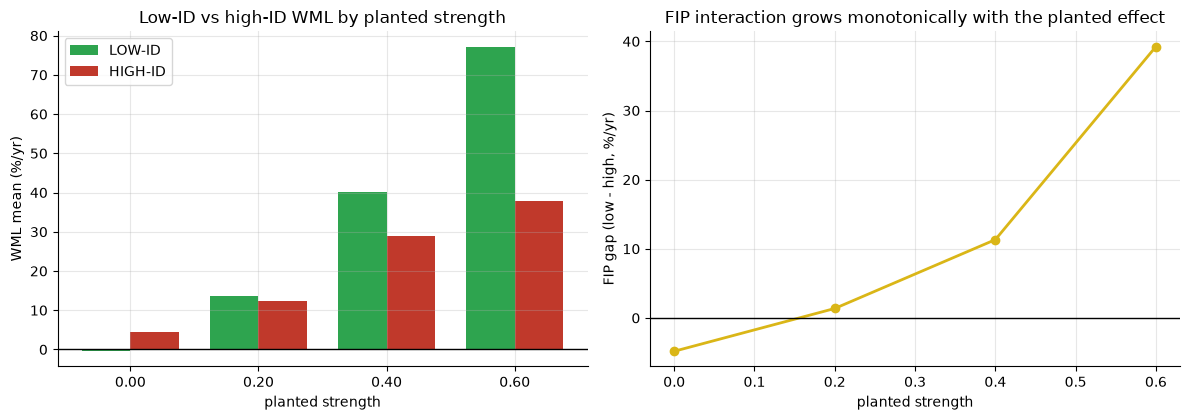

 mom_strength  low_id_mean_ann  low_id_t  high_id_mean_ann  high_id_t  fip_gap_ann   n
          0.0           -0.005    -0.089             0.044      0.951       -0.048 107
          0.2            0.136     2.604             0.122      2.127        0.014 107
          0.4            0.402     6.980             0.289      4.738        0.113 107
          0.6            0.772     9.869             0.380      5.990        0.392 107


In [2]:
ctrl = st.synthetic_control(strengths=(0.0, 0.20, 0.40, 0.60), frac=FRAC, seed=510)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
x = np.arange(len(ctrl)); w = 0.38
axes[0].bar(x - w/2, ctrl['low_id_mean_ann']*100, w, color=GREEN, label='LOW-ID')
axes[0].bar(x + w/2, ctrl['high_id_mean_ann']*100, w, color=RED, label='HIGH-ID')
axes[0].axhline(0, c='k', lw=1)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'{s:.2f}' for s in ctrl['mom_strength']])
axes[0].set_xlabel('planted strength'); axes[0].set_ylabel('WML mean (%/yr)')
axes[0].set_title('Low-ID vs high-ID WML by planted strength'); axes[0].legend()
axes[1].plot(ctrl['mom_strength'], ctrl['fip_gap_ann']*100, 'o-', c=AMBER, lw=2)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('planted strength'); axes[1].set_ylabel('FIP gap (low - high, %/yr)')
axes[1].set_title('FIP interaction grows monotonically with the planted effect')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine scores ~0 at the null and recovers a positive, monotone FIP gap when the effect is planted. A faithful detector -- so the real-tape result is the market's verdict, not the method's.

### 4b -- The information-discreteness distribution (real panel)

What does ID look like on the latest cross-section? We expect a spread around 0, with the smoothest trenders at the negative (low-ID) tail.

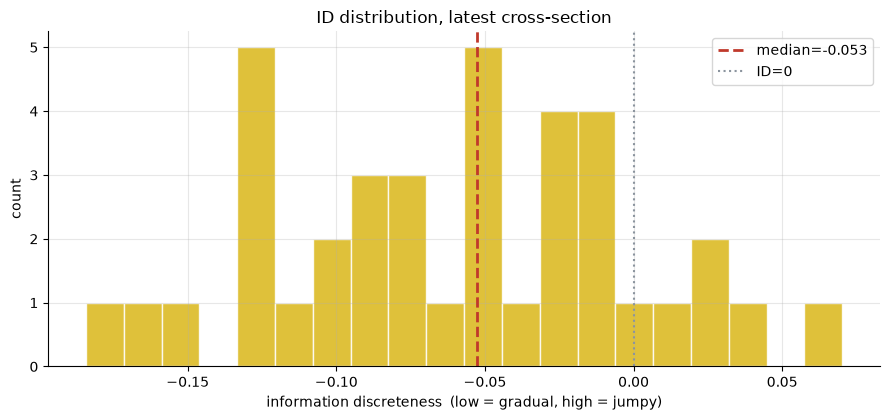

ID median: -0.053 | range: -0.184 .. +0.070


In [3]:
if HAVE_REAL:
    idm = st.information_discreteness(prices, mp)
    last_id = idm.iloc[-1].dropna()
    fig, ax = plt.subplots(figsize=(9.0, 4.3))
    ax.hist(last_id, bins=20, color=AMBER, edgecolor='white', alpha=0.85)
    ax.axvline(last_id.median(), c=RED, lw=2, ls='--', label=f'median={last_id.median():+.3f}')
    ax.axvline(0, c=GREY, lw=1.5, ls=':', label='ID=0')
    ax.set_xlabel('information discreteness  (low = gradual, high = jumpy)')
    ax.set_ylabel('count')
    ax.set_title('ID distribution, latest cross-section')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'ID median: {last_id.median():+.3f} | range: {last_id.min():+.3f} .. {last_id.max():+.3f}')
else:
    print('ID distribution requires the real cache.')

### 4c -- Real panel: the low-ID vs high-ID WML race

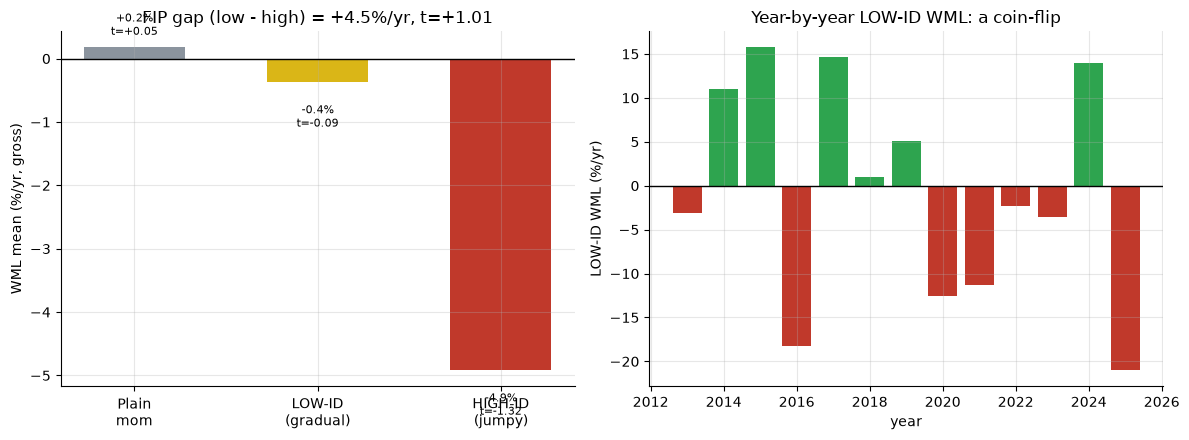

LOW-ID: -0.37%/yr (t -0.09) | HIGH-ID: -4.92%/yr (t -1.32) | FIP: +4.55%/yr (t +1.01)


In [4]:
if HAVE_REAL:
    lo_m, lo_t = s_lo['mean']*100, s_lo['tstat']
    hi_m, hi_t = s_hi['mean']*100, s_hi['tstat']
    base_m, base_t = s_base['mean']*100, s_base['tstat']
    fip_m, fip_t = s_fip['mean']*100, s_fip['tstat']
    lo_y = lo.copy(); lo_y['year'] = lo_y.index.year
    annual = lo_y.groupby('year')['wml_gross'].apply(lambda x: float((1+x).prod()-1))
else:
    lo_m, lo_t = R['low_mean'], R['low_t']
    hi_m, hi_t = R['high_mean'], R['high_t']
    base_m, base_t = R['base_mean'], R['base_t']
    fip_m, fip_t = R['fip_mean'], R['fip_t']
    annual = pd.Series(R['annual']) / 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
labels = ['Plain\nmom', 'LOW-ID\n(gradual)', 'HIGH-ID\n(jumpy)']
vals = [base_m, lo_m, hi_m]; ts = [base_t, lo_t, hi_t]
axes[0].bar(labels, vals, color=[GREY, AMBER, RED], width=0.55)
axes[0].axhline(0, c='k', lw=1)
for i, (v, t) in enumerate(zip(vals, ts)):
    axes[0].text(i, v + (0.2 if v >= 0 else -0.7), f'{v:+.1f}%\nt={t:+.2f}', ha='center', fontsize=8)
axes[0].set_ylabel('WML mean (%/yr, gross)')
axes[0].set_title(f'FIP gap (low - high) = {fip_m:+.1f}%/yr, t={fip_t:+.2f}')
col_yr = [GREEN if v > 0 else RED for v in annual.values]
axes[1].bar(annual.index, annual.values*100, color=col_yr)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('year'); axes[1].set_ylabel('LOW-ID WML (%/yr)')
axes[1].set_title('Year-by-year LOW-ID WML: a coin-flip')
plt.tight_layout(); plt.show()
print(f'LOW-ID: {lo_m:+.2f}%/yr (t {lo_t:+.2f}) | HIGH-ID: {hi_m:+.2f}%/yr (t {hi_t:+.2f}) | '
      f'FIP: {fip_m:+.2f}%/yr (t {fip_t:+.2f})')

> The LOW-ID book that should carry the premium earns **-0.37%/yr** at HAC *t* = **-0.09** -- zero. The positive interaction (**+4.55%/yr**) comes from the high-ID book being *more* negative, not from the gradual book being positive. H2 (momentum concentrated in low-ID) is rejected on this tape.

### 4d -- The label-shuffle placebo (seed-robust)

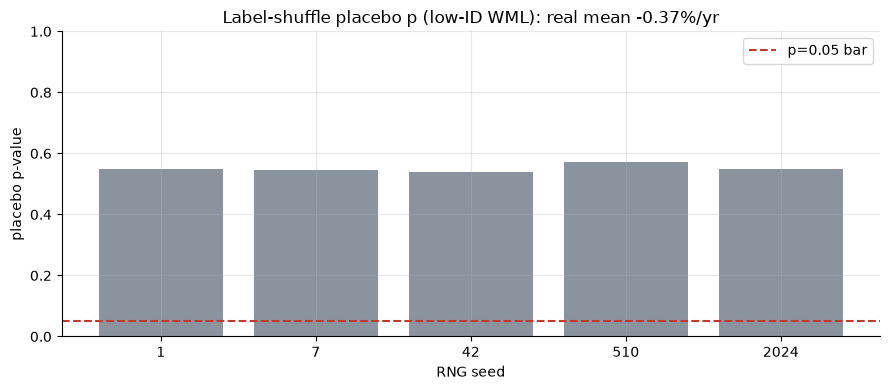

p across seeds: [0.55, 0.545, 0.54, 0.573, 0.547]
Main p (1000 perms): 0.558 | placebo mean +0.18%/yr


In [5]:
if HAVE_REAL:
    seeds = [1, 7, 42, 510, 2024]
    ps = []
    for sd in seeds:
        pl = st.placebo_pvalue(mp, prices, id_side='low', frac=FRAC, n_perm=400, seed=sd)
        ps.append(pl['p_value'])
    pl_main = st.placebo_pvalue(mp, prices, id_side='low', frac=FRAC, n_perm=1000, seed=510)
    real_mean = pl_main['real_mean_ann']*100
    fig, ax = plt.subplots(figsize=(9.0, 4.0))
    ax.bar([str(s) for s in seeds], ps, color=GREY)
    ax.axhline(0.05, c=RED, ls='--', lw=1.5, label='p=0.05 bar')
    ax.set_ylim(0, 1); ax.set_xlabel('RNG seed'); ax.set_ylabel('placebo p-value')
    ax.set_title(f'Label-shuffle placebo p (low-ID WML): real mean {real_mean:+.2f}%/yr'); ax.legend()
    plt.tight_layout(); plt.show()
    print(f'p across seeds: {[round(p,3) for p in ps]}')
    print(f'Main p (1000 perms): {pl_main["p_value"]:.3f} | placebo mean {pl_main["placebo_mean_ann"]*100:+.2f}%/yr')
else:
    print('Placebo seeds (frozen):', R['placebo_seeds'], '| p =', R['placebo_p'])

> The placebo p is **0.56**, stable across five seeds (0.54--0.57). The real low-ID mean sits *below* the centre of its own shuffled null. There is no FIP edge here to shuffle away.

### 4e -- Costs: the gradual book is negative net

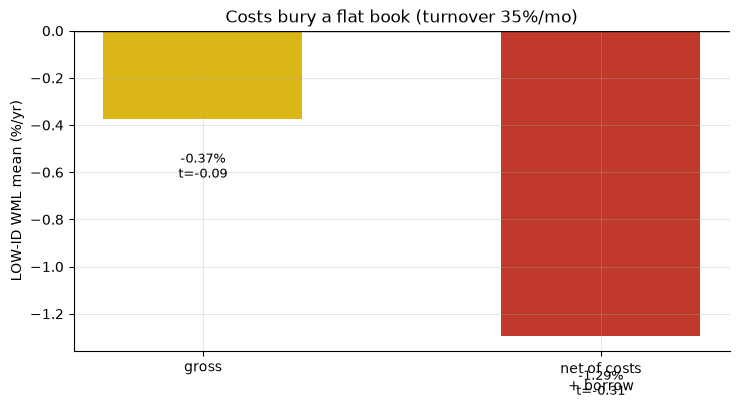

LOW-ID WML gross -0.37%/yr (t -0.09) -> net -1.29%/yr (t -0.31)


In [6]:
if HAVE_REAL:
    lo_net = st.long_short(mp, prices=prices, id_side='low', frac=FRAC,
                           cost_bps=COST_BPS, borrow_ann_bps=BORROW_BPS)
    s_g = st.summary(lo['wml_gross']); s_n = st.summary(lo_net['wml_net'])
    g_m, n_m = s_g['mean']*100, s_n['mean']*100
    g_t, n_t = s_g['tstat'], s_n['tstat']
    to = lo['turnover'].mean()*100
else:
    g_m, n_m = R['low_mean'], R['low_net_mean']
    g_t, n_t = R['low_t'], R['low_net_t']; to = R['turnover']
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['gross', 'net of costs\n+ borrow'], [g_m, n_m], color=[AMBER, RED], width=0.5)
ax.axhline(0, c='k', lw=1)
for i, (v, t) in enumerate(zip([g_m, n_m], [g_t, n_t])):
    ax.text(i, v + (0.1 if v >= 0 else -0.25), f'{v:+.2f}%\nt={t:+.2f}', ha='center', fontsize=9)
ax.set_ylabel('LOW-ID WML mean (%/yr)')
ax.set_title(f'Costs bury a flat book (turnover {to:.0f}%/mo)')
plt.tight_layout(); plt.show()
print(f'LOW-ID WML gross {g_m:+.2f}%/yr (t {g_t:+.2f}) -> net {n_m:+.2f}%/yr (t {n_t:+.2f})')

## 5 -- The verdict

- **Signal `NONE`** -- LOW-ID WML -0.37%/yr (HAC *t* -0.09), FIP interaction +4.55%/yr (HAC *t* +1.01); neither clears |t| >= 2, and the seed-robust placebo (p = 0.56) puts the real mean below its own null.
- **Tradability `MIRAGE`** -- net -1.29%/yr (*t* -0.31) after costs + borrow at 35%/mo turnover. Nothing to monetise.
- **Does gradual beat jumpy? `MIXED`** -- the sign is on the theory's side and the synthetic control proves the detector works, but the magnitude is statistically indistinguishable from zero on 38 large-cap survivors.

## 6 -- Could you trade it?

No, on three counts:

1. **Dead base book.** Plain large-cap momentum pays ~0 (+0.18%/yr here); conditioning a flat signal cannot manufacture a premium.
2. **Thin double-sort.** 38 names split at median ID then sorted into 30% legs leaves ~6 names per leg -- noisy, high-turnover, expensive.
3. **Survivorship cuts the FIP slice hardest.** Gradual losers drifting into delisting are precisely the low-ID short candidates a survivor basket omits.

## 7 -- Going further

- **Delisting-complete universe.** The original FIP result is on broad CRSP with delisting returns. Feed [`strategy.long_short`](../frog_in_the_pan/strategy.py) a delisting-complete panel to lift the survivorship bias on the short leg.
- **[507 Cross-Sectional-Momentum](../../507-cross-sectional-momentum/)** -- the unconditioned base WML this study refines.
- **[509 Intermediate-Momentum](../../509-intermediate-momentum/)** -- conditions on the *timing* of past returns; FIP conditions on their *continuity*.
- **[237 Residual-Momentum](../../237-residual-momentum/)** -- strips factor exposure instead of conditioning on path shape.

*Think the frog-in-the-pan premium survives net of costs on a delisting-complete universe? Fork this, add the delisted names, and show the low-ID WML at t > 2 net. That is the bar.*